In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import sys
sys.path.append('/content/drive/MyDrive/DeepfakeProject')

In [4]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import json,os
from torch.utils.data import DataLoader
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from torchvision import models

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [10]:
from models import build_model
from dataset import DeepfakeDataset

In [11]:
!unzip /content/drive/MyDrive/DeepfakeProject/faces.zip

Streaming output truncated to the last 5000 lines.
  inflating: content/faces/val/real/original__633/f004.jpg  
  inflating: content/faces/val/real/original__633/f001.jpg  
  inflating: content/faces/val/real/original__633/f000.jpg  
  inflating: content/faces/val/real/original__633/f002.jpg  
   creating: content/faces/val/real/original__078/
  inflating: content/faces/val/real/original__078/f003.jpg  
  inflating: content/faces/val/real/original__078/f004.jpg  
  inflating: content/faces/val/real/original__078/f001.jpg  
  inflating: content/faces/val/real/original__078/f000.jpg  
  inflating: content/faces/val/real/original__078/f002.jpg  
   creating: content/faces/val/real/original__836/
  inflating: content/faces/val/real/original__836/f003.jpg  
  inflating: content/faces/val/real/original__836/f004.jpg  
  inflating: content/faces/val/real/original__836/f001.jpg  
  inflating: content/faces/val/real/original__836/f000.jpg  
  inflating: content/faces/val/real/original__836/f002

In [12]:
test_ds = DeepfakeDataset(
    root='/content/content/faces',
    split='test',
    augment=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=5,
    shuffle=False,
    num_workers=2
)

print(f'Test samples: {len(test_ds)}')

[test ]  150 sequences | augment=False
Test samples: 150


In [13]:
model = build_model('transformer')
model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 170MB/s]


In [15]:
checkpoint = torch.load(
    f'/content/drive/MyDrive/DeepfakeProject/outputs/checkpoints/best_model.pth',
    map_location=device
)

model.load_state_dict(checkpoint['model_state'])
model.eval()

print(f'Loaded model from epoch {checkpoint["epoch"]}')
print(f'Val accuracy : {checkpoint["val_acc"]:.2f}%')

Loaded model from epoch 10
Val accuracy : 85.33%


In [16]:
all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for frames, labels in test_loader:
        frames  = frames.to(device)
        outputs = model(frames)
        probs   = torch.sigmoid(outputs).squeeze()
        preds   = (probs > 0.5).long()

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.long().numpy())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print(f'Total test samples: {len(all_labels)}')
print(f'Real (0): {(all_labels==0).sum()} | '
      f'Fake (1): {(all_labels==1).sum()}')


Total test samples: 150
Real (0): 75 | Fake (1): 75


In [17]:
accuracy = (all_preds == all_labels).mean() * 100
auc      = roc_auc_score(all_labels, all_probs)

print(f'\n=== Test Metrics ===')
print(f'Accuracy  : {accuracy:.2f}%')
print(f'AUC-ROC   : {auc:.4f}')
print(f'\nClassification Report:')
print(classification_report(
    all_labels, all_preds,
    target_names=['REAL', 'FAKE']))



=== Test Metrics ===
Accuracy  : 88.67%
AUC-ROC   : 0.9623

Classification Report:
              precision    recall  f1-score   support

        REAL       0.91      0.85      0.88        75
        FAKE       0.86      0.92      0.89        75

    accuracy                           0.89       150
   macro avg       0.89      0.89      0.89       150
weighted avg       0.89      0.89      0.89       150



In [19]:
metrics = {
    'accuracy' : round(accuracy, 4),
    'auc_roc'  : round(auc, 4),
    'epoch'    : checkpoint['epoch'],
    'val_acc'  : checkpoint['val_acc'],
}
with open(f'/content/drive/MyDrive/DeepfakeProject/outputs/results/test_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

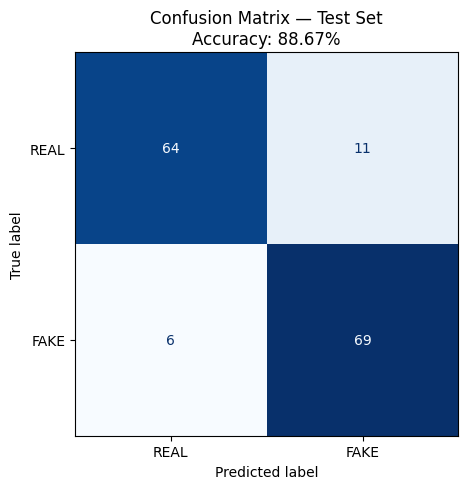

In [21]:
cm  = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['REAL', 'FAKE'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — Test Set\n'
             f'Accuracy: {accuracy:.2f}%', fontsize=12)
plt.tight_layout()
plt.savefig(f'/content/drive/MyDrive/DeepfakeProject/outputs/results/confusion_matrix.png', dpi=150)
plt.show()

In [23]:
wrong_indices = np.where(all_preds != all_labels)[0]
print(f'\nWrong predictions: {len(wrong_indices)} / {len(all_labels)}')


Wrong predictions: 17 / 150


In [25]:
from PIL import Image

Text(0.5, 0.98, 'Wrong Predictions')

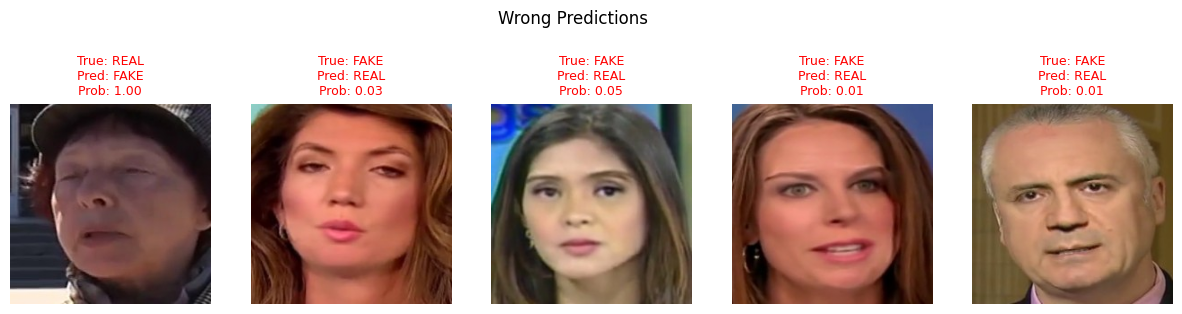

In [30]:
fig, axes = plt.subplots(1, min(5, len(wrong_indices)),
                          figsize=(15, 4))

for i, idx in enumerate(wrong_indices[10:15]):
    folder, label = test_ds.samples[idx]
    files = sorted(os.listdir(folder))

    mid_frame = Image.open(
        f'{folder}/{files[len(files)//2]}').convert('RGB')

    axes[i].imshow(mid_frame)
    true_lbl = 'REAL' if label == 0 else 'FAKE'
    pred_lbl = 'REAL' if all_preds[idx] == 0 else 'FAKE'
    axes[i].set_title(
        f'True: {true_lbl}\nPred: {pred_lbl}\n'
        f'Prob: {all_probs[idx]:.2f}',
        fontsize=9, color='red')
    axes[i].axis('off')

plt.suptitle('Wrong Predictions', fontsize=12)